# Demand Forecasting with Uncertainty Quantification

This project uses machine learning to forecast retail demand and quantify
forecast uncertainty using P10, P50, and P90 prediction intervals.

## 1. Dataset

The project uses the Store Item Demand Forecasting Challenge dataset.

The dataset contains daily sales records for 10 stores and 50 items from
January 2013 to December 2017.

The main columns are:

- `date` — date of the sale
- `store` — store identifier
- `item` — product identifier
- `sales` — number of units sold

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

df = pd.read_csv("/content/train[1].csv")

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

print("Number of stores:", df["store"].nunique())
print("Number of items:", df["item"].nunique())
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSales statistics:")
print(df["sales"].describe())

df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

Libraries loaded successfully!
Dataset loaded successfully!
Rows: 913000
Columns: 4
Number of stores: 10
Number of items: 50
Start date: 2013-01-01
End date: 2017-12-31

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Sales statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64
date     datetime64[ns]
store             int64
item              int64
sales             int64
dtype: object


## 2. Feature Engineering

To help the forecasting model learn demand patterns, several time-based
features are created.

### Calendar Features

The date is converted into useful calendar information such as:

- Year
- Month
- Day of week
- Day of month
- Week of year

### Lag Features

Previous sales are used as predictors:

- `lag_1` — sales from the previous day
- `lag_7` — sales from 7 days earlier
- `lag_14` — sales from 14 days earlier

### Rolling Statistics

Recent demand behavior is summarized using:

- 7-day rolling mean
- 14-day rolling mean
- 7-day rolling standard deviation

Only past observations are used to calculate these features to avoid
data leakage.

In [8]:
# Time-based features

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

print(df.head())

        date  store  item  sales  year  month  day_of_week  day_of_month  \
0 2013-01-01      1     1     13  2013      1            1             1   
1 2013-01-02      1     1     11  2013      1            2             2   
2 2013-01-03      1     1     14  2013      1            3             3   
3 2013-01-04      1     1     13  2013      1            4             4   
4 2013-01-05      1     1     10  2013      1            5             5   

   week_of_year  
0             1  
1             1  
2             1  
3             1  
4             1  


In [10]:
# Sort the data by store, item, and date
df = df.sort_values(["store", "item", "date"])

# Create lag features
df["lag_1"] = df.groupby(["store", "item"])["sales"].shift(1)
df["lag_7"] = df.groupby(["store", "item"])["sales"].shift(7)
df["lag_14"] = df.groupby(["store", "item"])["sales"].shift(14)

print(df[["date", "store", "item", "sales", "lag_1", "lag_7", "lag_14"]].head(20))

         date  store  item  sales  lag_1  lag_7  lag_14
0  2013-01-01      1     1     13    NaN    NaN     NaN
1  2013-01-02      1     1     11   13.0    NaN     NaN
2  2013-01-03      1     1     14   11.0    NaN     NaN
3  2013-01-04      1     1     13   14.0    NaN     NaN
4  2013-01-05      1     1     10   13.0    NaN     NaN
5  2013-01-06      1     1     12   10.0    NaN     NaN
6  2013-01-07      1     1     10   12.0    NaN     NaN
7  2013-01-08      1     1      9   10.0   13.0     NaN
8  2013-01-09      1     1     12    9.0   11.0     NaN
9  2013-01-10      1     1      9   12.0   14.0     NaN
10 2013-01-11      1     1      9    9.0   13.0     NaN
11 2013-01-12      1     1      7    9.0   10.0     NaN
12 2013-01-13      1     1     10    7.0   12.0     NaN
13 2013-01-14      1     1     12   10.0   10.0     NaN
14 2013-01-15      1     1      5   12.0    9.0    13.0
15 2013-01-16      1     1      7    5.0   12.0    11.0
16 2013-01-17      1     1     16    7.0    9.0 

In [12]:
# Rolling statistics using only past sales

df["rolling_mean_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_14"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

df["rolling_std_7"] = (
    df.groupby(["store", "item"])["sales"]
      .transform(lambda x: x.shift(1).rolling(7).std())
)

print(df[[
    "date", "store", "item", "sales",
    "lag_1", "lag_7",
    "rolling_mean_7", "rolling_mean_14", "rolling_std_7"
]].tail(15))

             date  store  item  sales  lag_1  lag_7  rolling_mean_7  \
912985 2017-12-17     10    50     86   52.0   69.0       64.714286   
912986 2017-12-18     10    50     53   86.0   54.0       67.142857   
912987 2017-12-19     10    50     54   53.0   67.0       67.000000   
912988 2017-12-20     10    50     51   54.0   67.0       65.142857   
912989 2017-12-21     10    50     63   51.0   72.0       62.857143   
912990 2017-12-22     10    50     75   63.0   72.0       61.571429   
912991 2017-12-23     10    50     70   75.0   52.0       62.000000   
912992 2017-12-24     10    50     76   70.0   86.0       64.571429   
912993 2017-12-25     10    50     51   76.0   53.0       63.142857   
912994 2017-12-26     10    50     41   51.0   54.0       62.857143   
912995 2017-12-27     10    50     63   41.0   51.0       61.000000   
912996 2017-12-28     10    50     59   63.0   63.0       62.714286   
912997 2017-12-29     10    50     74   59.0   75.0       62.142857   
912998

In [14]:
# Remove rows where lag/rolling features are not available

feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]

df = df.dropna(subset=feature_columns).copy()

print("Rows after removing incomplete history:", len(df))
print("Missing values in features:")
print(df[feature_columns].isnull().sum())

Rows after removing incomplete history: 906000
Missing values in features:
lag_1              0
lag_7              0
lag_14             0
rolling_mean_7     0
rolling_mean_14    0
rolling_std_7      0
dtype: int64


In [16]:
# Time-based train/test split

train = df[df["date"] < "2017-01-01"].copy()
test = df[df["date"] >= "2017-01-01"].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training rows: 723500
Testing rows: 182500

Training period:
2013-01-15 00:00:00 to 2016-12-31 00:00:00

Testing period:
2017-01-01 00:00:00 to 2017-12-31 00:00:00


In [18]:
!pip install lightgbm -q

import lightgbm as lgb

print("LightGBM installed successfully!")

LightGBM installed successfully!


In [20]:
# Features used by the ML model

features = [
    "store",
    "item",
    "year",
    "month",
    "day_of_week",
    "day_of_month",
    "week_of_year",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_std_7"
]

target = "sales"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Number of features:", len(features))
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Number of features: 13
Training feature shape: (723500, 13)
Testing feature shape: (182500, 13)


## 3. Quantile Forecasting Model

A LightGBM gradient boosting model is used for demand forecasting.

Instead of producing only one prediction, three quantile models are trained:

- **P10** — 10th percentile, representing lower expected demand
- **P50** — 50th percentile, representing the central forecast
- **P90** — 90th percentile, representing higher expected demand

The P10-P90 range forms a nominal 80% prediction interval.

In [22]:
# Train the P50 (median) quantile model

p50_model = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.50,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

p50_model.fit(X_train, y_train)

print("P50 model trained successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1489
[LightGBM] [Info] Number of data points in the train set: 723500, number of used features: 13
[LightGBM] [Info] Start training from score 46.000000
P50 model trained successfully!


In [24]:
# Generate P50 predictions for the test data

p50_pred = p50_model.predict(X_test)

print("P50 predictions generated!")
print(p50_pred[:10])

P50 predictions generated!
[20.04345742 12.48113363 14.76494364 15.07129297 16.17294136 17.38717093
 17.58992302 18.93087267 12.9606063  14.83032941]


## 4. Model Evaluation

The forecasting model is evaluated using both point accuracy and
prediction interval calibration.

### Point Forecast Accuracy

The P50 forecast is evaluated using:

- **MAE (Mean Absolute Error)** — average absolute prediction error
- **RMSE (Root Mean Squared Error)** — gives more weight to larger errors

### Prediction Interval Calibration

The P10-P90 interval has a nominal coverage of 80%.

Coverage measures the percentage of actual demand values that fall
between the predicted P10 and P90 values.

An empirical coverage close to 80% indicates good calibration.


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, p50_pred)
rmse = np.sqrt(mean_squared_error(y_test, p50_pred))

print("P50 MAE:", round(mae, 2))
print("P50 RMSE:", round(rmse, 2))

P50 MAE: 6.22
P50 RMSE: 8.1


In [28]:
# Train the P10 (10th percentile) model

p10_model = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.10,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

p10_model.fit(X_train, y_train)

print("P10 model trained successfully!")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.109507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1489
[LightGBM] [Info] Number of data points in the train set: 723500, number of used features: 13
[LightGBM] [Info] Start training from score 19.000000
P10 model trained successfully!


In [30]:
# Train the P90 (90th percentile) model

p90_model = lgb.LGBMRegressor(
    objective="quantile",
    alpha=0.90,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

p90_model.fit(X_train, y_train)

print("P90 model trained successfully!")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1489
[LightGBM] [Info] Number of data points in the train set: 723500, number of used features: 13
[LightGBM] [Info] Start training from score 90.000000
P90 model trained successfully!


In [32]:
# Generate P10, P50, and P90 predictions

p10_pred = p10_model.predict(X_test)
p50_pred = p50_model.predict(X_test)
p90_pred = p90_model.predict(X_test)

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
for i in range(10):
    print(
        f"P10: {p10_pred[i]:.2f} | "
        f"P50: {p50_pred[i]:.2f} | "
        f"P90: {p90_pred[i]:.2f} | "
        f"Actual: {y_test.iloc[i]}"
    )

Predictions generated successfully!

First 10 predictions:
P10: 14.59 | P50: 20.04 | P90: 26.29 | Actual: 19
P10: 8.40 | P50: 12.48 | P90: 18.22 | Actual: 15
P10: 10.37 | P50: 14.76 | P90: 20.39 | Actual: 10
P10: 10.16 | P50: 15.07 | P90: 20.21 | Actual: 16
P10: 11.40 | P50: 16.17 | P90: 21.68 | Actual: 14
P10: 12.02 | P50: 17.39 | P90: 22.60 | Actual: 24
P10: 13.00 | P50: 17.59 | P90: 24.10 | Actual: 14
P10: 14.15 | P50: 18.93 | P90: 25.79 | Actual: 20
P10: 8.34 | P50: 12.96 | P90: 18.02 | Actual: 18
P10: 10.50 | P50: 14.83 | P90: 20.88 | Actual: 11


In [35]:
# Check prediction interval coverage

inside_interval = (y_test >= p10_pred) & (y_test <= p90_pred)

coverage = inside_interval.mean()

print("Prediction interval coverage:", round(coverage * 100, 2), "%")
print("Target coverage: 80%")

interval_width = p90_pred - p10_pred

print("Average interval width:", round(interval_width.mean(), 2))

Prediction interval coverage: 79.63 %
Target coverage: 80%
Average interval width: 19.87


## 5. Overconfidence Analysis

The model's uncertainty estimates are also evaluated during high-demand
periods.

The highest 10% of demand observations are treated as high-demand cases.
Their prediction interval coverage is compared with the overall coverage.

Lower coverage during high-demand periods can indicate that the model
does not fully capture the uncertainty associated with demand spikes.

In [37]:
# Analyze model performance on high-demand days

results = test[["date", "store", "item", "sales"]].copy()

results["p10"] = p10_pred
results["p50"] = p50_pred
results["p90"] = p90_pred

results["interval_width"] = results["p90"] - results["p10"]

# Define high-demand days as the top 10% of actual demand
high_demand_threshold = results["sales"].quantile(0.90)

high_demand = results[results["sales"] >= high_demand_threshold]

high_demand_coverage = (
    (high_demand["sales"] >= high_demand["p10"]) &
    (high_demand["sales"] <= high_demand["p90"])
).mean()

print("High-demand threshold:", round(high_demand_threshold, 2))
print("High-demand observations:", len(high_demand))
print("Coverage on high-demand days:",
      round(high_demand_coverage * 100, 2), "%")
print("Average interval width on high-demand days:",
      round(high_demand["interval_width"].mean(), 2))

High-demand threshold: 104.0
High-demand observations: 18289
Coverage on high-demand days: 75.96 %
Average interval width on high-demand days: 29.51


## 6. Inventory Decision

The prediction intervals are translated into an inventory decision by
comparing two stocking strategies.

- **P50 strategy:** stock according to the central demand forecast.
- **P90 strategy:** stock according to the upper demand forecast.

The analysis considers both leftover inventory and stockouts.

For this illustrative analysis, leftover inventory has a cost of 1 unit
per item, while a stockout has a cost of 3 units per item. This reflects
a situation where stockouts are more expensive than holding excess stock.

In [39]:
# Inventory decision analysis

actual = y_test.values

# Strategy 1: Use P50 as inventory level
stock_p50 = p50_pred

# Strategy 2: Use P90 as inventory level
stock_p90 = p90_pred

# Cost assumptions
holding_cost = 1
stockout_cost = 3


def calculate_inventory_cost(stock, actual):
    leftover = np.maximum(stock - actual, 0)
    stockout = np.maximum(actual - stock, 0)

    total_cost = (
        leftover * holding_cost +
        stockout * stockout_cost
    )

    return leftover, stockout, total_cost


# P50 strategy
leftover_p50, stockout_p50, cost_p50 = calculate_inventory_cost(
    stock_p50, actual
)

# P90 strategy
leftover_p90, stockout_p90, cost_p90 = calculate_inventory_cost(
    stock_p90, actual
)

print("P50 Strategy")
print("Average leftover:", round(leftover_p50.mean(), 2))
print("Average stockout:", round(stockout_p50.mean(), 2))
print("Total cost:", round(cost_p50.sum(), 2))
print("Average cost per observation:", round(cost_p50.mean(), 2))

print("\nP90 Strategy")
print("Average leftover:", round(leftover_p90.mean(), 2))
print("Average stockout:", round(stockout_p90.mean(), 2))
print("Total cost:", round(cost_p90.sum(), 2))
print("Average cost per observation:", round(cost_p90.mean(), 2))

P50 Strategy
Average leftover: 2.94
Average stockout: 3.28
Total cost: 2332647.83
Average cost per observation: 12.78

P90 Strategy
Average leftover: 10.36
Average stockout: 0.43
Total cost: 2124788.7
Average cost per observation: 11.64


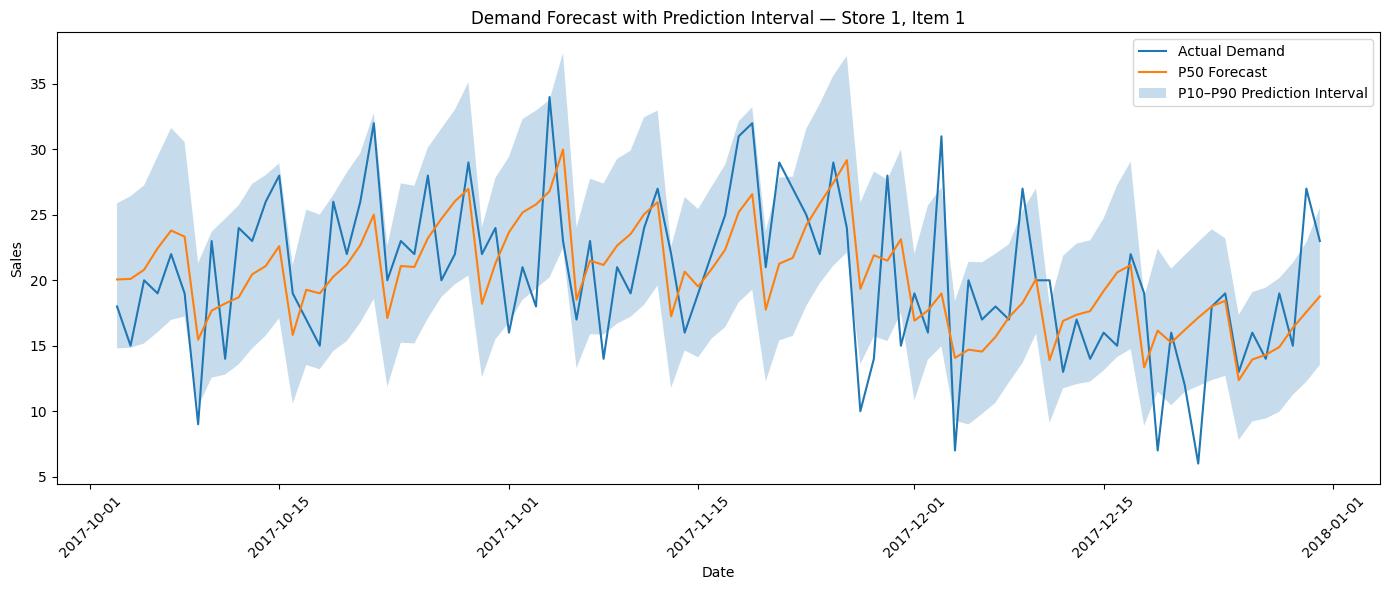

In [41]:
# Create results table

results = test[["date", "store", "item", "sales"]].copy()

results["p10"] = p10_pred
results["p50"] = p50_pred
results["p90"] = p90_pred

# Select one store-item combination for visualization
plot_data = results[
    (results["store"] == 1) &
    (results["item"] == 1)
].sort_values("date").tail(90)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["sales"],
    label="Actual Demand"
)

plt.plot(
    plot_data["date"],
    plot_data["p50"],
    label="P50 Forecast"
)

plt.fill_between(
    plot_data["date"],
    plot_data["p10"],
    plot_data["p90"],
    alpha=0.25,
    label="P10–P90 Prediction Interval"
)

plt.title("Demand Forecast with Prediction Interval — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

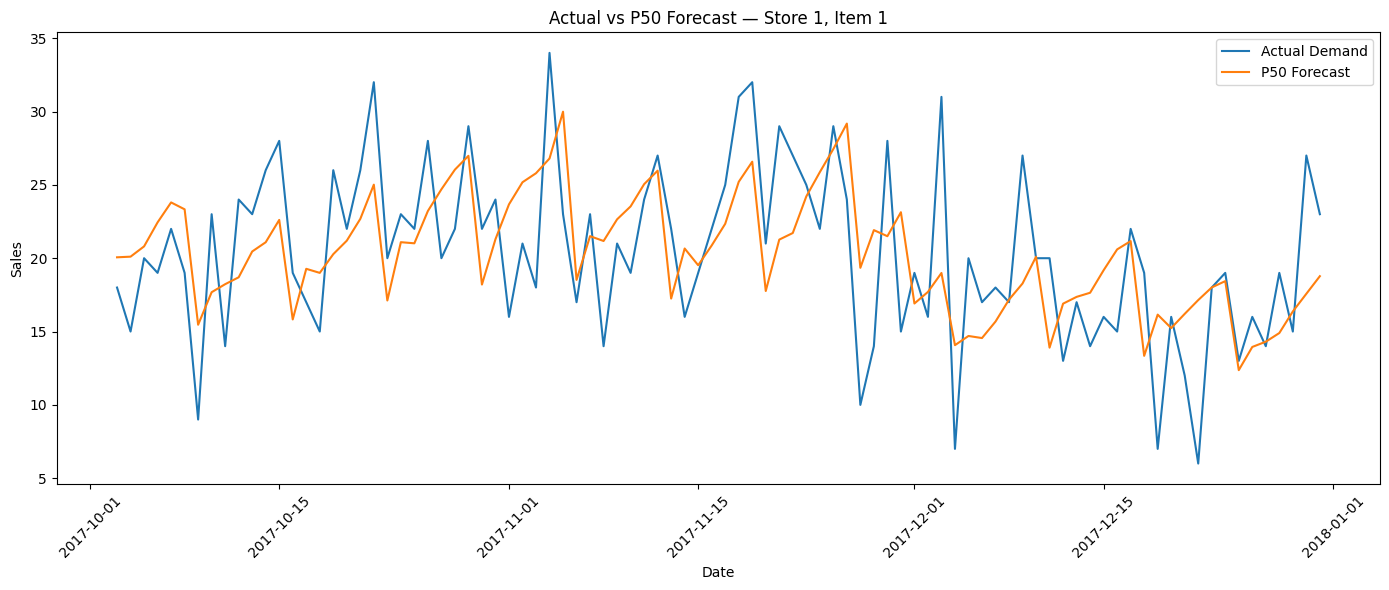

In [43]:
# Actual vs P50 forecast

plot_data = results[
    (results["store"] == 1) &
    (results["item"] == 1)
].sort_values("date").tail(90)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["date"],
    plot_data["sales"],
    label="Actual Demand"
)

plt.plot(
    plot_data["date"],
    plot_data["p50"],
    label="P50 Forecast"
)

plt.title("Actual vs P50 Forecast — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

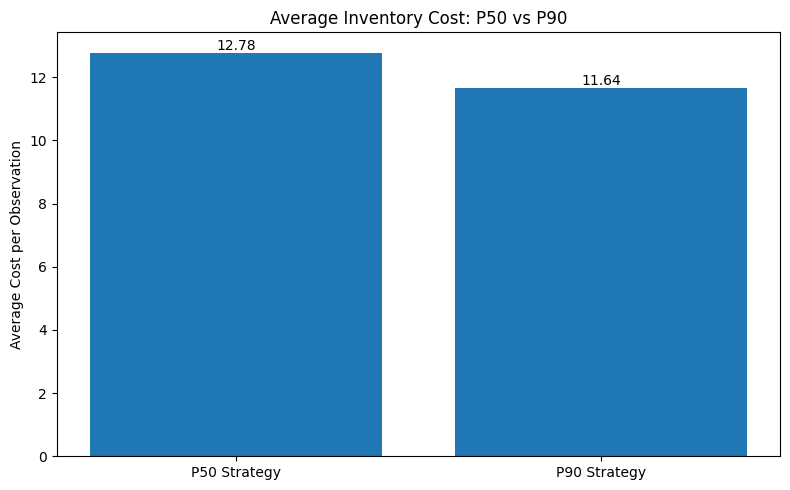

In [44]:
# Compare inventory strategies

strategies = ["P50 Strategy", "P90 Strategy"]
average_costs = [cost_p50.mean(), cost_p90.mean()]

plt.figure(figsize=(8, 5))

bars = plt.bar(strategies, average_costs)

plt.title("Average Inventory Cost: P50 vs P90")
plt.ylabel("Average Cost per Observation")

for bar, value in zip(bars, average_costs):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## 7. Conclusion

This project demonstrates demand forecasting with uncertainty
quantification using quantile regression.

The P50 model achieved a MAE of 6.22 and an RMSE of 8.10 on the
2017 test period.

The P10-P90 prediction interval achieved 79.63% empirical coverage,
which is close to the nominal 80% coverage target. The average interval
width was 19.87 units.

For the highest-demand 10% of observations, interval coverage decreased
to 75.96%, showing that the model is somewhat less reliable during
demand spikes.

For inventory planning, the P90 strategy produced fewer stockouts
than the P50 strategy. Under the assumed cost structure, the P90
strategy also had a lower average inventory cost (11.64 versus 12.78).

Overall, the results show how uncertainty-aware forecasting can provide
more useful information for inventory planning than a single point
forecast.